In [43]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [44]:
def vector_norm(x):
    return math.sqrt(sum((abs(val)) ** 2 for val in x))

In [45]:
def relaxation_method(A, B, w=1.3, eps=1e-3, max_iter=100):
    n = len(B)
    prev_x = np.zeros(n)
    new_x = prev_x.copy()

    x_history = []

    for step in range(1, max_iter + 1):
        for i in range(n):
            new_values_sum = A[i, :i] @ new_x[:i]
            old_values_sum = A[i, (i + 1):] @ prev_x[(i + 1):]
            new_x[i] = (B[i] - (old_values_sum + new_values_sum)) / A[i, i]
            new_x[i] = (new_x[i] * w) + (prev_x[i] * (1 - w))

        x_history.append(new_x.copy())

        if vector_norm(A @ new_x - B) < eps:
            print(f"Решение после {step} итераций; X = {new_x}")
            return new_x, x_history

        prev_x = new_x.copy()

    print("Решение не сходится")
    return new_x, x_history

In [46]:
def plot_convergence(x_history):
    x_history = np.array(x_history)
    iterations = np.arange(len(x_history))

    plt.figure(figsize=(12, 6))

    for i in range(x_history.shape[1]):
        plt.plot(iterations, x_history[:, i], label=f'Корень X{i + 1}')

    plt.title('Сходимость корней')
    plt.xlabel('Итерация')
    plt.ylabel('Значение')
    plt.legend()
    plt.grid(True)
    plt.show()

In [47]:
A = np.array([[0.5, 0.2, 0.1],
              [0.3, 0.7, 0.4],
              [0.4, 0.1, 0.5]])
B = np.array([1.4, 2.1, 1.8])

In [48]:
final_solution, history = relaxation_method(A, B)

Решение после 18 итераций; X = [1.99109891 1.12801904 1.78156667]


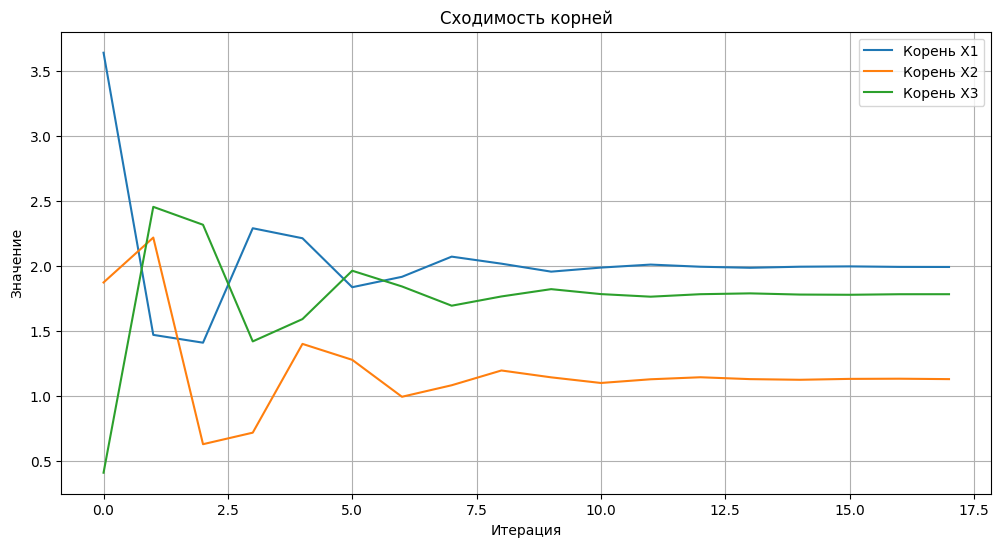

In [49]:
plot_convergence(history)